# SmartCart Clustering System

## Import Libraries & Packages

In [1]:
# Importing Python Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

# Importing Sklearn Packages
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

## Load the Dataset

In [2]:
df = pd.read_csv("smartcart_customers.csv")

## Collect Basic Info

In [3]:
print(df.shape)
df.info()
df.sample(5)

(2240, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
1884,7679,1985,PhD,Single,30298.0,0,0,19-05-2014,48,6,...,6,1,0,1,1,1,3,3,0,0
1842,7419,1968,Master,Divorced,27071.0,1,0,23-04-2014,90,8,...,0,2,3,2,2,0,3,6,0,0
1809,1990,1974,PhD,Single,63159.0,0,0,05-11-2012,74,965,...,89,86,37,1,3,5,8,3,0,0
1696,1890,1971,2n Cycle,Together,42033.0,1,1,19-09-2012,95,11,...,2,0,7,1,1,0,2,7,0,0
1654,13,1947,PhD,Widow,25358.0,0,1,22-07-2013,57,19,...,0,0,8,2,1,0,3,6,0,0


## Data Cleaning & Pre-processing

### 1. Check for Missing values

In [4]:
# Check for Missing values
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().sum()/len(df))*100
})
missing_val = missing[missing["missing_count"]>0]
print("No missing values found!") if missing_val.empty else missing_val

,missing_count,missing_%
Income,24,1.071429


### 2. Check for Duplicate values

In [5]:
# Check for Duplicate values
duplicates = df.duplicated().sum()

if duplicates > 0:
    duplicate_rows = df[df.duplicated(keep=False)].drop_duplicates()
    display(duplicate_rows)
    df.drop_duplicates(inplace=True)
    df.reset_index(inplace=True)
    print("New Shape:", df.shape)
else:
    print("No duplicates found!")

No duplicates found!


### 3. Inspect Data Inconsistency

In [6]:
# Inspect data Inconsistency
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### A. Change the dtype of Dt_Customer: object --> datetime64[ns]

In [7]:
# Convert dtype of Dt_Customer from object to datetime64[ns]
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format = "%d-%m-%Y"
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

### 4. Fix column names & column data

In [8]:
# Fix column names & column data
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

### 5. Handle Missing values

In [9]:
# Handle Missing values
df["Income"] = df["Income"].fillna(df["Income"].median())

### 6. Identify Unique values in Categorical columns

In [10]:
for col in df.select_dtypes(include="object"):
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts(normalize=True)*100)
    print("*"*100)

Column: Education
Unique values: 5
Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: proportion, dtype: float64
****************************************************************************************************
Column: Marital_Status
Unique values: 8
Marital_Status
Married     38.571429
Together    25.892857
Single      21.428571
Divorced    10.357143
Widow        3.437500
Alone        0.133929
Absurd       0.089286
YOLO         0.089286
Name: proportion, dtype: float64
****************************************************************************************************


### 7. Get a Summary of the Dataset

In [11]:
# Get a Summary of the Dataset
pd.set_option("display.max_columns", None)
df.describe(include="all")

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2240,2240,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52237.975446,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,NaN,NaN,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


## Feature Engineering

### 1. Adding new Features

### A. Age

In [12]:
# Adding new Feature: Age
df["Age"] = 2026 - df["Year_Birth"]

### B. Customer_Tenure_Days

In [13]:
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days

### C. Total_Spending

In [14]:
df["Total_Spending"] =  df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

### D. Total_Children

In [15]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

### 2. Structuring Columns

### A. Education

In [16]:
# Education
print("Before:")
display(pd.DataFrame(df["Education"].value_counts()))

df["Education"] = df["Education"].replace(
    {
        "Graduation": "Graduate",
        "PhD": "Postgraduate",
        "Master": "Postgraduate",
        "2n Cycle": "Undergraduate",
        "Basic": "Undergraduate"
    }
)

print("*"*100)
print("After:")
display(pd.DataFrame(df["Education"].value_counts()))

Before:


,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


****************************************************************************************************
After:


,count
Education,
Graduate,1127
Postgraduate,856
Undergraduate,257


### B. Organise Marital_Status

In [17]:
# Marital_Status
display(pd.DataFrame(df["Marital_Status"].value_counts()))

df["Marital_Status"] = df["Marital_Status"].replace(
    {
        "Married": "Partner",
        "Together": "Partner",
        "Single": "Alone",
        "Divorced": "Alone",
        "Widow": "Alone",
        "Alone": "Alone",
        "Absurd": "Alone",
        "YOLO": "Alone"
    }
)
print("*"*100)
print("After:")
display(pd.DataFrame(df["Marital_Status"].value_counts()))

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


****************************************************************************************************
After:


,count
Marital_Status,
Partner,1444
Alone,796


### 3. Drop unnecessary Columns

In [18]:
# Drop unnecessary columns
column_1 = ["ID", "Year_Birth", "Dt_Customer"]
column_2 = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
column_3 = ["Kidhome", "Teenhome"]
columns = column_1 + column_2 + column_3
df.drop(columns=columns, inplace=True)

## Exploratory Data Analysis

### 1. Income Analysis

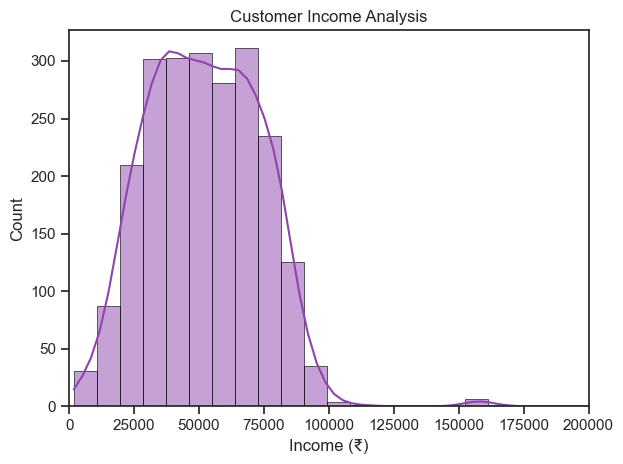

In [19]:
# Income Analysis
sns.set_theme(style="ticks")
fig,ax = plt.subplots()

sns.histplot(
    x = df["Income"],
    bins = 75,
    color = "#8E44AD",
    edgecolor = "black",
    kde = True,
    ax = ax
)

plt.title("Customer Income Analysis")
plt.xlabel("Income (₹)")
plt.xlim(0,200000)
fig.tight_layout()
plt.show()

### 2. Total Spending Analysis

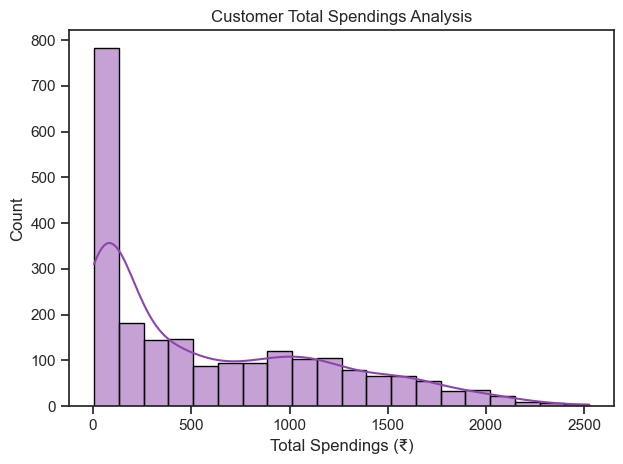

In [20]:
# Total Spendings Analysis
sns.set_theme(style="ticks")
fig,ax = plt.subplots()

sns.histplot(
    x = df["Total_Spending"],
    bins = 20,
    color = "#8E44AD",
    edgecolor = "black",
    kde = True,
    ax = ax
)

plt.title("Customer Total Spendings Analysis")
plt.xlabel("Total Spendings (₹)")
fig.tight_layout()
plt.show()

### 3. Age Analysis

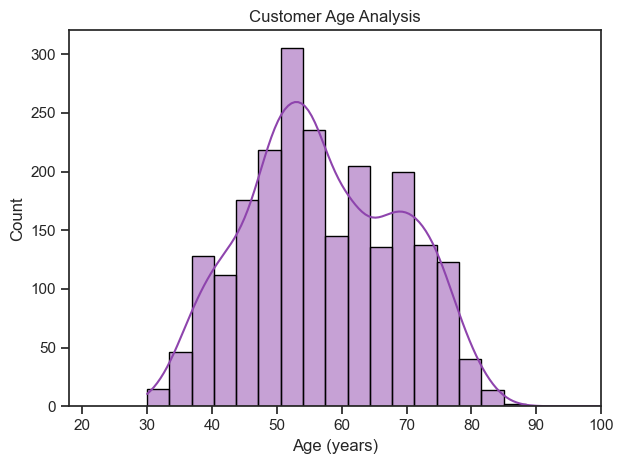

In [21]:
# Age Analysis
sns.set_theme(style="ticks")
fig,ax = plt.subplots()

sns.histplot(
    x = df["Age"],
    bins = 30,
    color = "#8E44AD",
    edgecolor = "black",
    kde = True,
    ax = ax
)

plt.title("Customer Age Analysis")
plt.xlabel("Age (years)")
plt.xlim(18,100)
fig.tight_layout()
plt.show()

### 4. Tenure Period Analysis

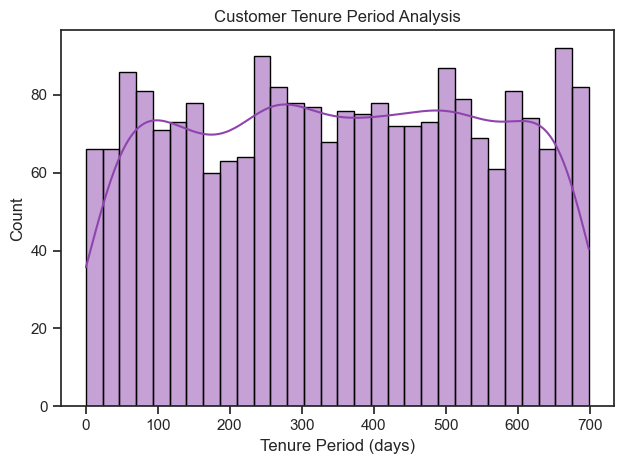

In [22]:
# Tenure period Analysis
sns.set_theme(style="ticks")
fig,ax = plt.subplots()

sns.histplot(
    x = df["Customer_Tenure_Days"],
    bins = 30,
    color = "#8E44AD",
    edgecolor = "black",
    kde = True,
    ax = ax
)

plt.title("Customer Tenure Period Analysis")
plt.xlabel("Tenure Period (days)")
fig.tight_layout()
plt.show()

### 5. Income v/s Spending w.r.t. Education

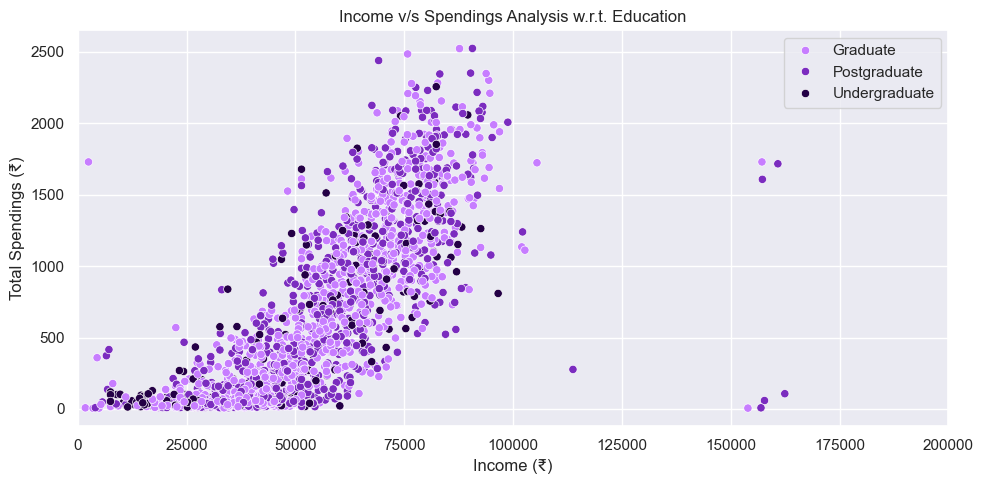

In [23]:
# Income v/s Spending w.r.t. Education
sns.set_theme(style="darkgrid")
fig,ax = plt.subplots(figsize=(10,5))

scatter_colors = [
    "#C77DFF", 
    "#7B2CBF",
    "#240046"   
]

sns.scatterplot(
    x = df["Income"],
    y = df["Total_Spending"],
    hue = df["Education"],
    palette = scatter_colors,
    ax = ax
)

plt.legend()
plt.title("Income v/s Spendings Analysis w.r.t. Education")
plt.xlabel("Income (₹)")
plt.ylabel("Total Spendings (₹)")
plt.xlim(0,200000)
fig.tight_layout()
plt.show()

### 6. Income v/s Spending w.r.t. Marital Status

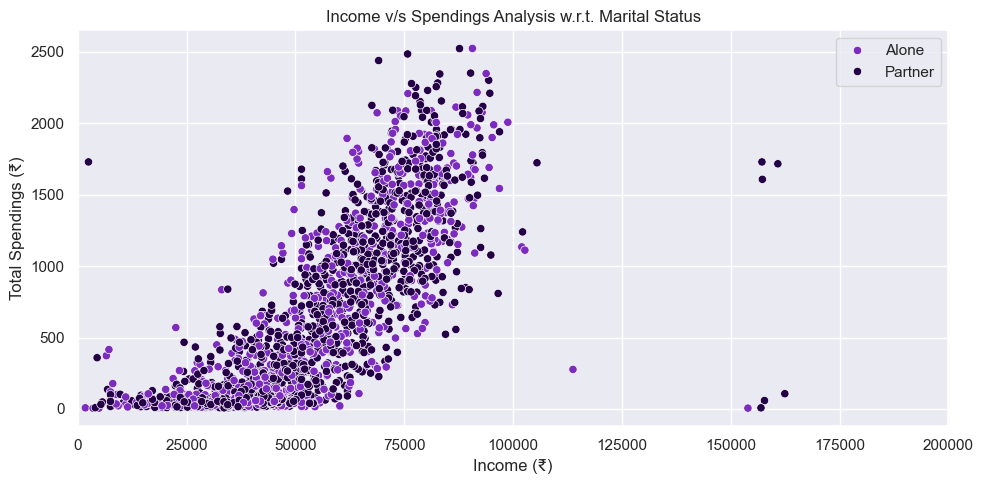

In [24]:
# Income v/s Spending w.r.t. Marital Status
sns.set_theme(style="darkgrid")
fig,ax = plt.subplots(figsize=(10,5))

scatter_colors = [
    "#7B2CBF",
    "#240046"   
]

sns.scatterplot(
    x = df["Income"],
    y = df["Total_Spending"],
    hue = df["Marital_Status"],
    palette = scatter_colors,
    ax = ax
)

plt.legend()
plt.title("Income v/s Spendings Analysis w.r.t. Marital Status")
plt.xlabel("Income (₹)")
plt.ylabel("Total Spendings (₹)")
plt.xlim(0,200000)
fig.tight_layout()
plt.show()

### 7. Age v/s Spending w.r.t. Education

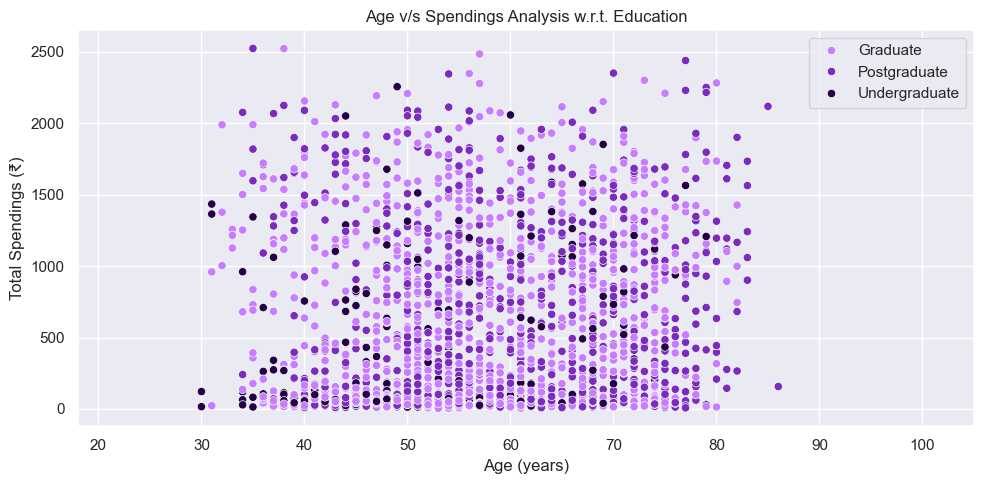

In [25]:
# Age v/s Spending w.r.t. Education
sns.set_theme(style="darkgrid")
fig,ax = plt.subplots(figsize=(10,5))

scatter_colors = [
    "#C77DFF", 
    "#7B2CBF",
    "#240046"   
]

sns.scatterplot(
    x = df["Age"],
    y = df["Total_Spending"],
    hue = df["Education"],
    palette = scatter_colors,
    ax = ax
)

plt.legend()
plt.title("Age v/s Spendings Analysis w.r.t. Education")
plt.xlabel("Age (years)")
plt.ylabel("Total Spendings (₹)")
plt.xlim(18,105)
fig.tight_layout()
plt.show()

### 8. Age v/s Spending w.r.t. Marital Status

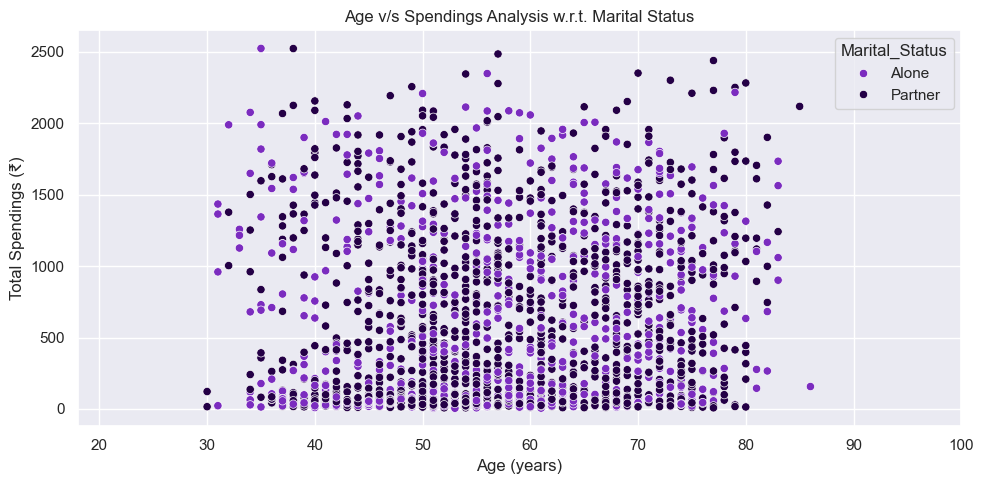

In [26]:
# Age v/s Spending w.r.t. Marital Status
sns.set_theme(style="darkgrid")
fig,ax = plt.subplots(figsize=(10,5))

scatter_colors = [
    "#7B2CBF",
    "#240046"   
]

sns.scatterplot(
    x = df["Age"],
    y = df["Total_Spending"],
    hue = df["Marital_Status"],
    palette = scatter_colors,
    ax = ax
)

plt.title("Age v/s Spendings Analysis w.r.t. Marital Status")
plt.xlabel("Age (years)")
plt.ylabel("Total Spendings (₹)")
plt.xlim(18,100)
fig.tight_layout()
plt.show()

### 9. Categorical Analysis

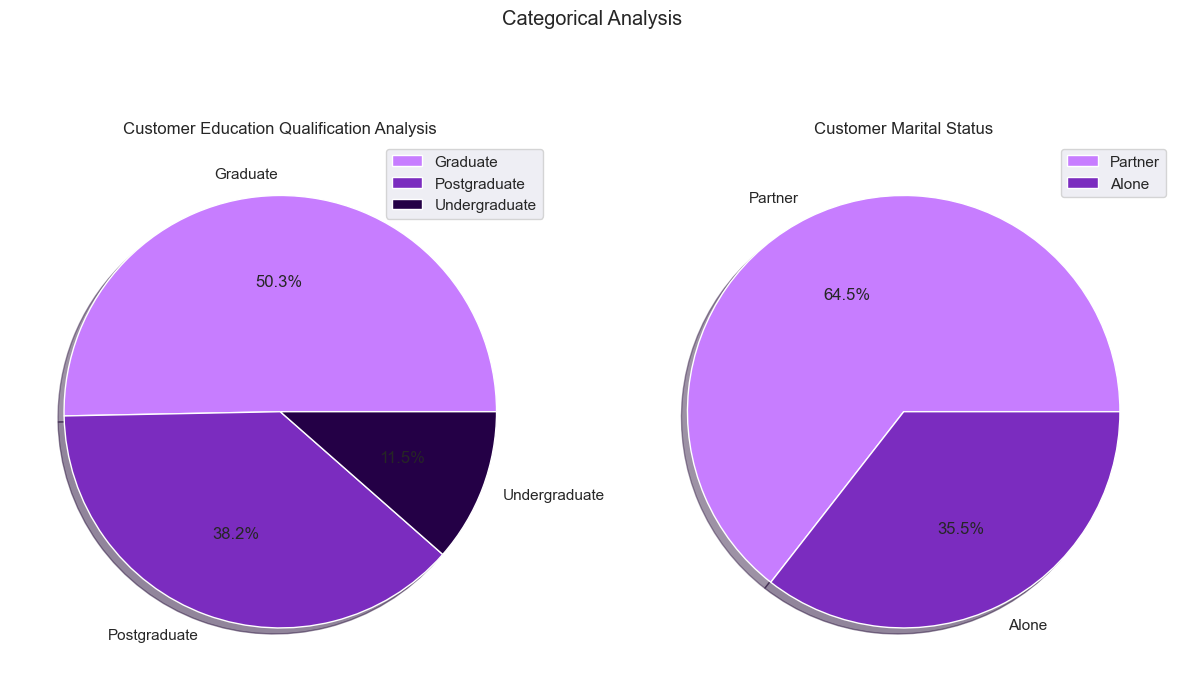

In [27]:
# Categorical Analysis
sns.set_theme(style="dark")
fig,ax = plt.subplots(1,2, figsize=(12,8))

education = df["Education"].value_counts().reset_index()
marital_status = df["Marital_Status"].value_counts().reset_index()

colors = [
    "#C77DFF", 
    "#7B2CBF",
    "#240046"   
]

ax[0].pie(
    education["count"],
    autopct = "%1.1f%%",
    labels = education["Education"],
    colors = colors,
    shadow = True
)
ax[0].legend()
ax[0].set_title("Customer Education Qualification Analysis")

ax[1].pie(
    marital_status["count"],
    autopct = "%1.1f%%",
    labels = marital_status["Marital_Status"],
    colors = colors,
    shadow = True
)
ax[1].legend()
ax[1].set_title("Customer Marital Status")

fig.suptitle("Categorical Analysis")
fig.tight_layout()
plt.show()

### 10. Outliers Detection using Boxplots

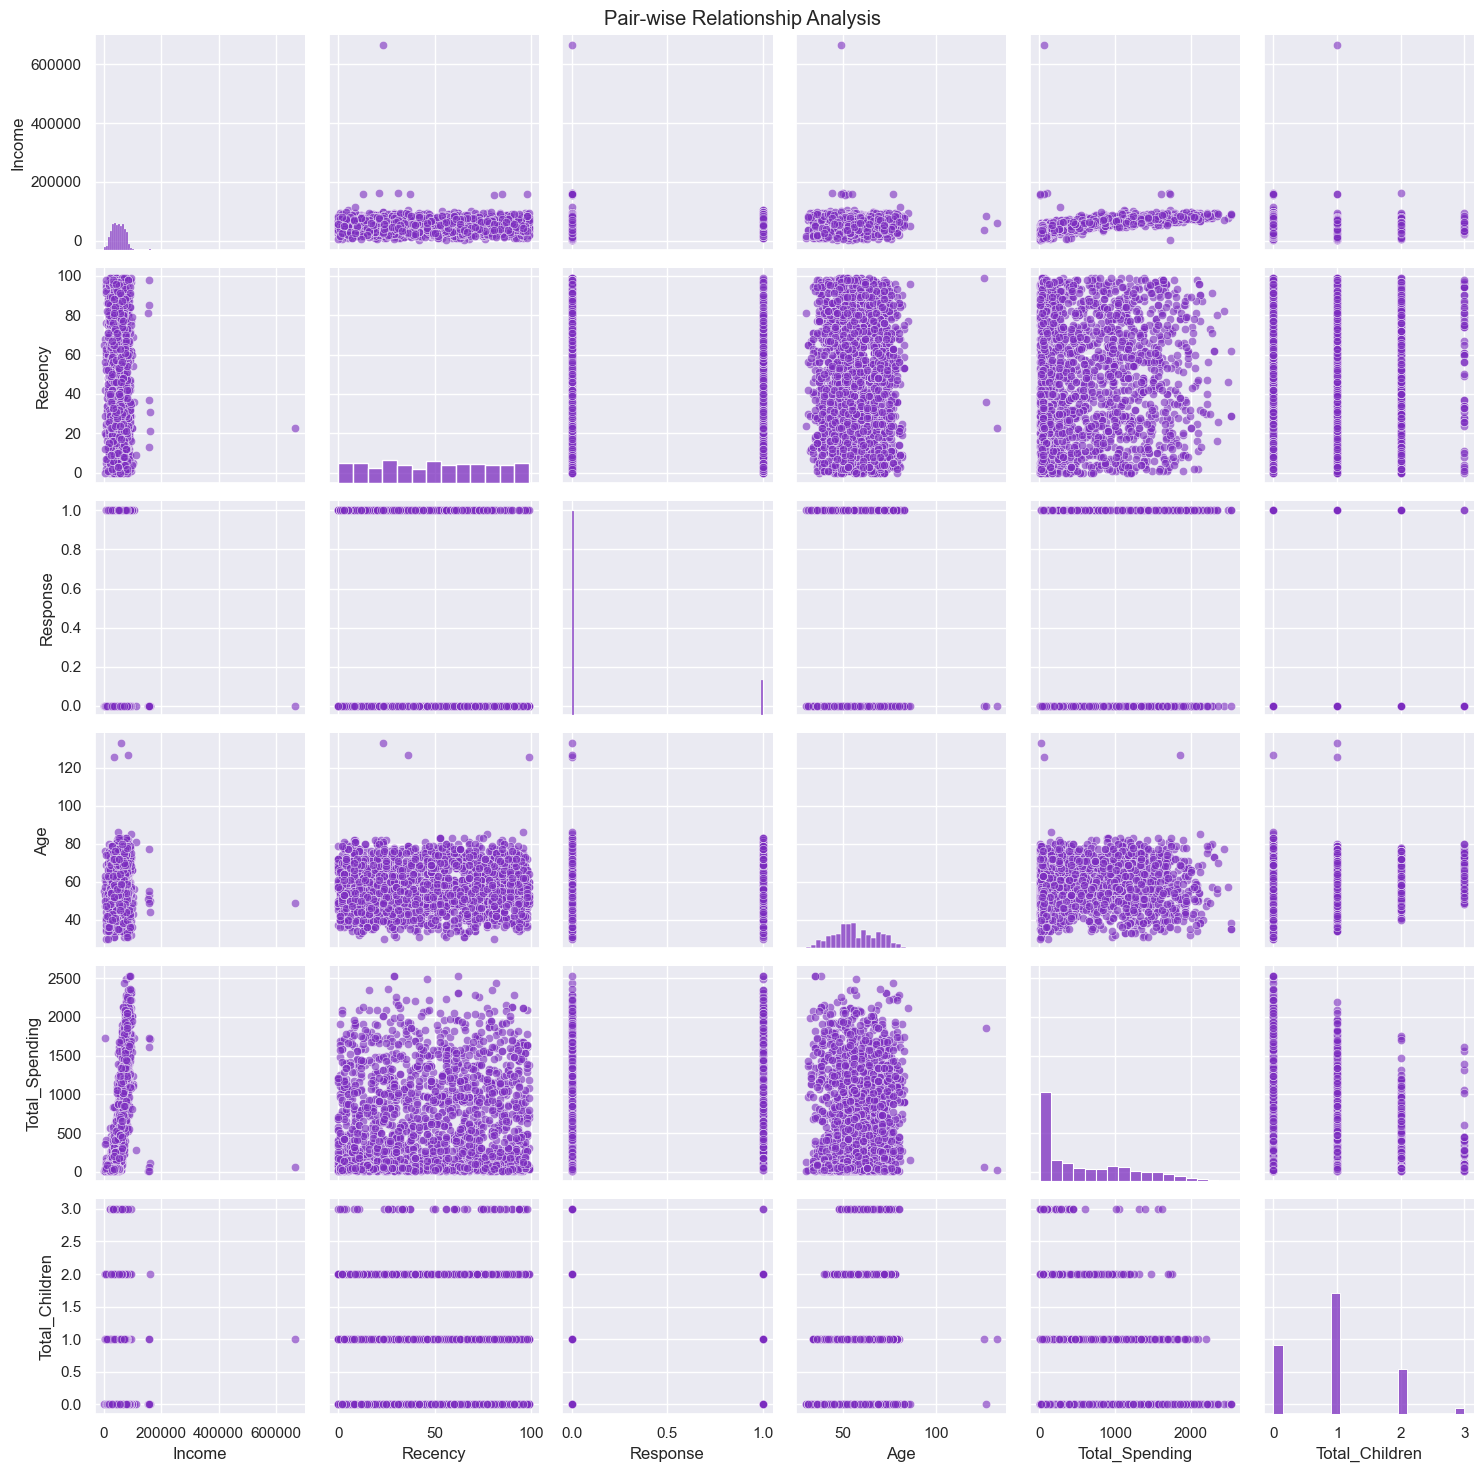

In [28]:
# Outliers Detection using Boxplots
sns.set_theme(style="darkgrid")

cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

fig = sns.pairplot(
    df[cols],
    plot_kws={"color": "#7B2CBF", "alpha": 0.6},
    diag_kws={"color": "#7B2CBF"}
)

fig.figure.suptitle("Pair-wise Relationship Analysis")
fig.figure.tight_layout()
plt.show()

### Removing Outliers

In [29]:
# Removing Outliers
print("Shape with Outliers:", df.shape)
df = df[df["Age"]<90]
df = df[df["Income"]<600_000]
print("Shape without Outliers:", df.shape)

Shape with Outliers: (2240, 15)
Shape without Outliers: (2236, 15)


### 11. Correlation Heatmap

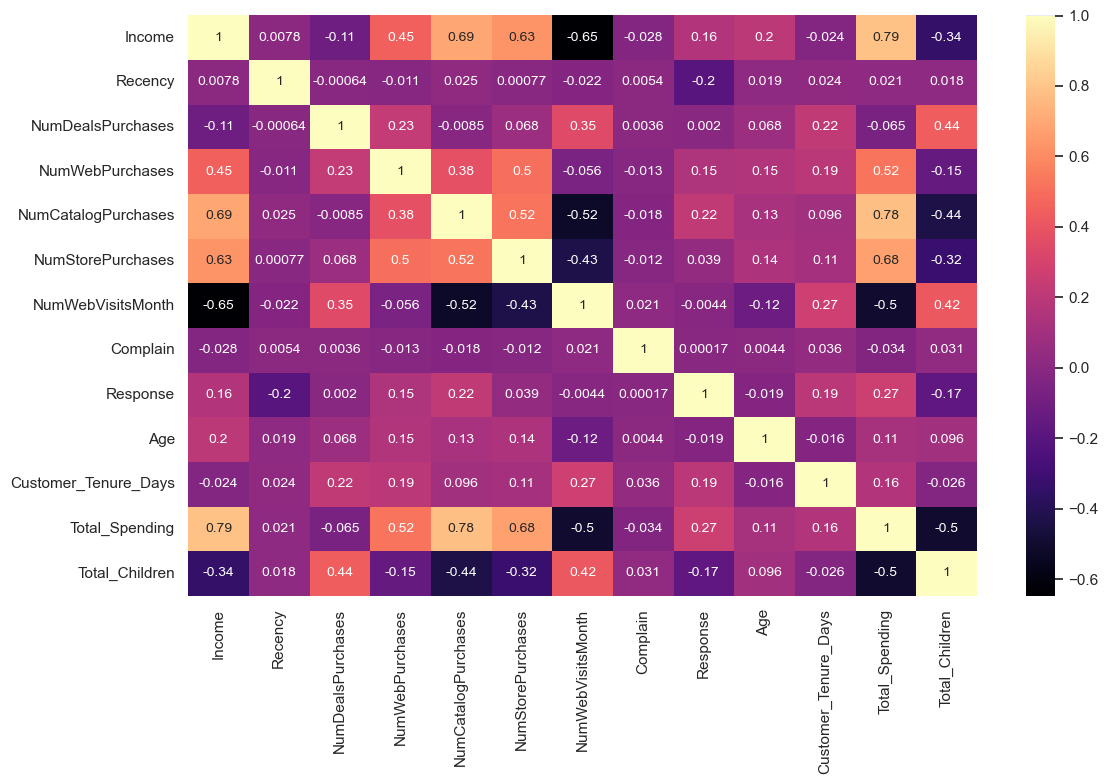

In [30]:
# Correlation Heatmap
corr = df.corr(numeric_only=True)
fig,ax = plt.subplots(figsize=(12,8))

sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":10},
    cmap = "magma"
)

fig.tight_layout()
plt.show()

In [31]:
df.sample(5)

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
1896,Undergraduate,Partner,24882.0,52,1,1,1,2,6,0,0,48,658,80,1
1630,Postgraduate,Partner,73059.0,36,1,9,3,13,4,0,0,79,302,1095,1
528,Graduate,Alone,61839.0,20,1,4,8,4,8,0,0,62,686,1895,0
1989,Graduate,Partner,58116.0,38,2,3,3,8,2,0,0,70,77,443,1
556,Postgraduate,Alone,54880.0,57,2,6,2,11,5,0,0,48,485,795,1


## Data Encoding

In [32]:
# Data Encoding
ohe = OneHotEncoder()

cat_cols = ["Education", "Marital_Status"]

encoded_df = ohe.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(
    encoded_df.toarray(),
    columns = ohe.get_feature_names_out(cat_cols),
    index = df.index
)

df = pd.concat([df.drop(cat_cols, axis=1), encoded_df], axis=1)

## Data Scaling

In [33]:
# Data Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Dimensionality Reduction

In [34]:
# Dimensionality Reduction
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Eigen Vectors:\n", pca.components_)

Explained Variance Ratio: [0.23163158 0.11385454 0.10405815]
Eigen Vectors:
 [[ 4.32495231e-01 -4.77962864e-06 -6.61546905e-02  2.73378035e-01
   4.09002511e-01  3.73746727e-01 -3.29131391e-01 -1.88136537e-02
   1.27218263e-01  9.66425138e-02  3.59536437e-02  4.50247045e-01
  -2.80189921e-01  7.79902112e-03  4.64731872e-02 -8.33185400e-02
   2.20964364e-02 -2.20964364e-02]
 [-3.99368915e-02 -3.14842072e-02 -4.80235286e-02 -3.11617872e-02
  -1.66793156e-02 -5.63142267e-02  3.49097435e-02  4.98712690e-03
   1.95332864e-01 -4.90583971e-02  3.66902408e-02 -8.27937537e-03
  -5.21665505e-02  5.44748637e-02 -4.65966398e-02 -1.44472010e-02
   6.85345977e-01 -6.85345977e-01]
 [ 6.65151990e-03 -6.20281283e-02  3.50940367e-01  2.12134792e-01
  -7.18924750e-03  5.95855957e-02  2.12323079e-01 -3.50386103e-02
   1.37876808e-01  2.21032653e-01  1.70522927e-01  1.45140775e-02
   2.43386612e-01 -5.30214386e-01  5.77767693e-01 -4.93182882e-02
   4.62099640e-02 -4.62099640e-02]]


## Data Visualisation

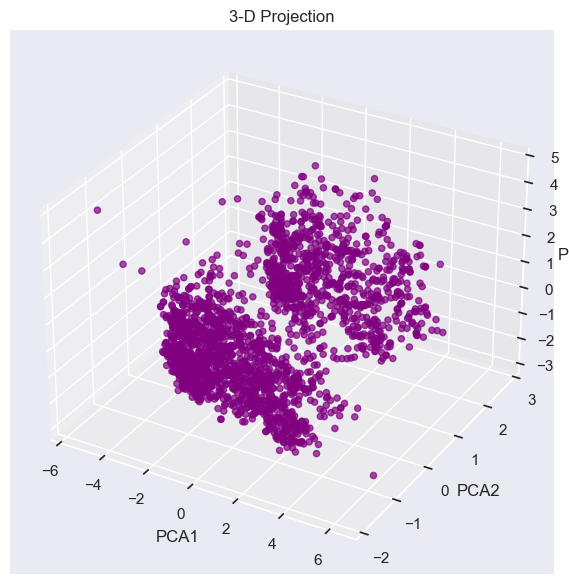

In [35]:
# Data Visualisation
sns.set_theme(style="dark")
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    xs = X_pca[:,0],
    ys = X_pca[:,1],
    zs = X_pca[:,2],
    color = "purple",
    alpha = 0.7
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3-D Projection")
fig.tight_layout()
plt.show()

In [36]:
df.sample(5)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Partner
1958,96843.0,60,1,6,11,10,2,0,1,36,432,1544,0,1.0,0.0,0.0,1.0,0.0
1903,29819.0,77,3,3,0,3,6,0,0,55,248,39,1,1.0,0.0,0.0,1.0,0.0
1052,69098.0,82,1,7,8,9,5,0,0,77,498,2440,0,0.0,1.0,0.0,0.0,1.0
1272,38808.0,21,4,5,1,4,8,0,1,54,672,246,1,1.0,0.0,0.0,1.0,0.0
2162,47320.0,10,6,5,1,8,6,0,0,69,332,414,1,1.0,0.0,0.0,0.0,1.0


## Choose an appropriate k value

### 1. Elbow Method

Elbow Point: 4


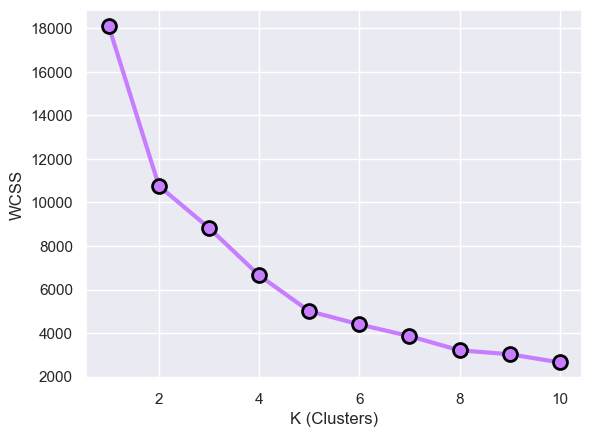

In [37]:
# Elbow Method
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters = k,
        init = "k-means++",
        random_state = 42
    )
    labels_kmeans = kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

sns.set_theme(style="darkgrid")

knee = KneeLocator(
    x = range(1,11),
    y = wcss,
    curve = "convex",
    direction = "decreasing"
)
print("Elbow Point:", knee.elbow)

sns.lineplot(
    x = range(1,11),
    y = wcss,
    linewidth = 3,
    color = "#C77DFF",
    marker = "o",
    mec = "black",
    mew = 2,
    markersize = 10
)
plt.xlabel("K (Clusters)")
plt.ylabel("WCSS")
plt.show()

### 2. Silhouette Score

Optimal k = 8
Best Silhouette Score: 0.40508588286950054


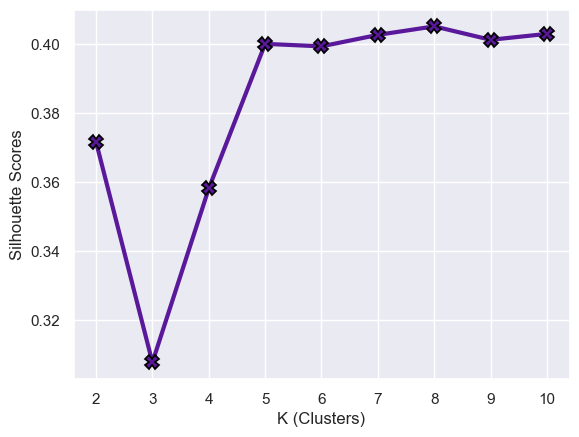

In [38]:
# Silhouette Score
ss = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters = k,
        init = "k-means++",
        random_state = 42
    )
    kmeans_labels = kmeans.fit_predict(X_pca)
    ss.append(silhouette_score(X_pca,kmeans_labels))

print("Optimal k =", range(2,21)[np.argmax(ss)])
print("Best Silhouette Score:", np.max(ss))

sns.set_theme(style="darkgrid")
sns.lineplot(
    x = range(2,11),
    y = ss,
    linewidth = 3,
    color = "#5A189A",
    marker = "X",
    mec = "black",
    mew = 1.25,
    markersize = 10
)

plt.xlabel("K (Clusters)")
plt.ylabel("Silhouette Scores")
plt.show()

### Combined Plots

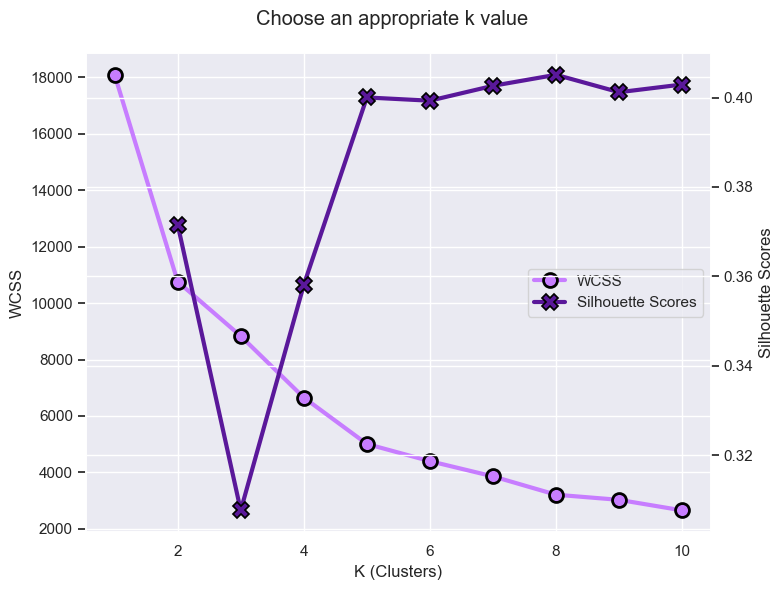

In [39]:
# Combined Plots
sns.set_theme(style="darkgrid")
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(
    range(1,11),
    wcss,
    color = "#C77DFF",
    linewidth = 3,
    marker = "o",
    mec = "black",
    mew = 2,
    markersize = 10,
    label = "WCSS"
)

ax1.set_xlabel("K (Clusters)")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(
    range(2,11),
    ss,
    color = "#5A189A",
    linewidth = 3,
    marker = "X",
    mec = "black",
    mew = 1.25,
    markersize = 12,
    label = "Silhouette Scores"
)

ax2.set_ylabel("Silhouette Scores")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center right"
)
fig.suptitle("Choose an appropriate k value")
fig.tight_layout()
plt.show()

### 3. Dendrogram

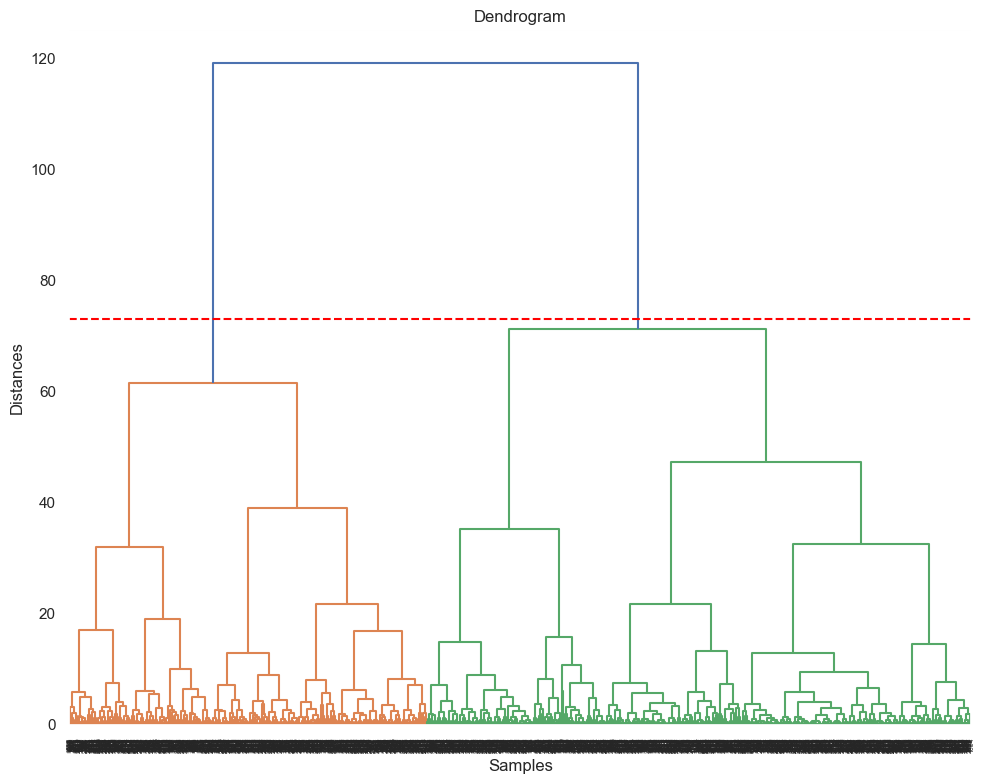

In [40]:
# Dendrogram
Z = linkage(X_pca, method="ward") # Linkage Matrix

fig = plt.figure(figsize=(10,8))
dendrogram(Z)
plt.title("Dendrogram")
plt.axhline(
    y=73, 
    color="red",
    linestyle = "--"
)
plt.xlabel("Samples")
plt.ylabel("Distances")
fig.tight_layout()
plt.show()

## Clustering

### 1. KMeans Clustering

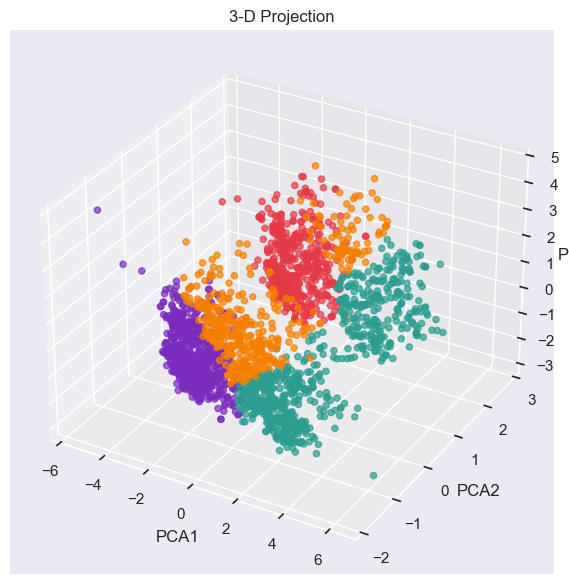

In [41]:
# KMeans Clustering
kmeans = KMeans(
    n_clusters = 4, # Elbow Method
    init = "k-means++",
    random_state = 42
)
kmeans_labels = kmeans.fit_predict(X_pca)

# Data Visualisation
sns.set_theme(style="dark")
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

colors = [
    "#7B2CBF",  # Purple
    "#F77F00",  # Orange
    "#2A9D8F",  # Teal
    "#E63946"   # Red
]
cmap = ListedColormap(colors)

ax.scatter(
    xs = X_pca[:,0],
    ys = X_pca[:,1],
    zs = X_pca[:,2],
    c = kmeans_labels,
    cmap = cmap,
    alpha = 0.7
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3-D Projection")
fig.tight_layout()
plt.show()

### 2. Agglomerative Clustering

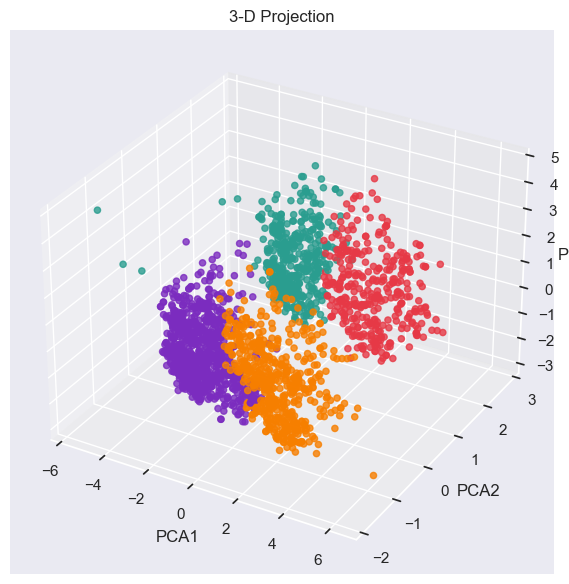

In [42]:
# Agglomerative CLustering
agglo_cluster = AgglomerativeClustering(
    n_clusters = 4, # Elbow Method
    metric = "euclidean",
    linkage = "ward"
)
agglo_labels = agglo_cluster.fit_predict(X_pca)

# Data Visualisation
sns.set_theme(style="dark")
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

colors = [
    "#7B2CBF",  # Purple
    "#F77F00",  # Orange
    "#2A9D8F",  # Teal
    "#E63946"   # Red
]

cmap = ListedColormap(colors)

ax.scatter(
    xs = X_pca[:,0],
    ys = X_pca[:,1],
    zs = X_pca[:,2],
    c = agglo_labels,
    cmap = cmap,
    alpha = 0.8
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3-D Projection")
fig.tight_layout()
plt.show()

#### Elbow Method => k=4 (Works best)
#### Silhouette Score => k=8
#### Dendrogram => k=3

## Categorising Customers using Clusters

In [43]:
# Categorising Clusters using Clusters
df["Cluster"] = agglo_labels
df.sample(5)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Partner,Cluster
2061,51381.5,82,2,3,0,3,6,0,0,45,394,47,1,0.0,1.0,0.0,1.0,0.0,2
1172,74214.0,3,1,8,2,5,5,0,0,36,672,1711,0,0.0,1.0,0.0,0.0,1.0,1
544,54058.0,56,2,4,6,8,3,0,0,50,390,662,1,1.0,0.0,0.0,0.0,1.0,1
1774,42664.0,44,1,1,0,3,6,0,0,59,103,24,1,1.0,0.0,0.0,0.0,1.0,0
2008,68805.0,73,1,3,1,7,2,0,0,67,285,283,1,0.0,1.0,0.0,1.0,0.0,2


## Clusters Visualisation

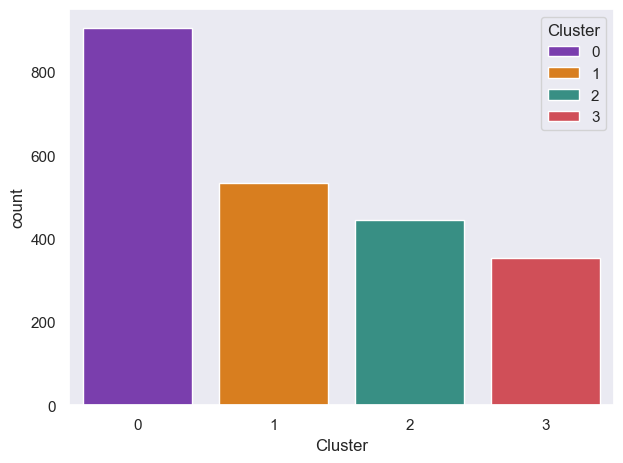

In [44]:
# Clusters Visualisation
colors = [
    "#7B2CBF",  # Purple
    "#F77F00",  # Orange
    "#2A9D8F",  # Teal
    "#E63946"   # Red
]

sns.set_theme(style="dark")
fig,ax = plt.subplots()

sns.countplot(
    x = df["Cluster"],
    palette = colors,
    hue = df["Cluster"],
    ax = ax
)

fig.tight_layout()
plt.show()

## Cluster Analysis

In [45]:
df["Cluster"].value_counts().reset_index()

,Cluster,count
0,0,905
1,1,534
2,2,444
3,3,353


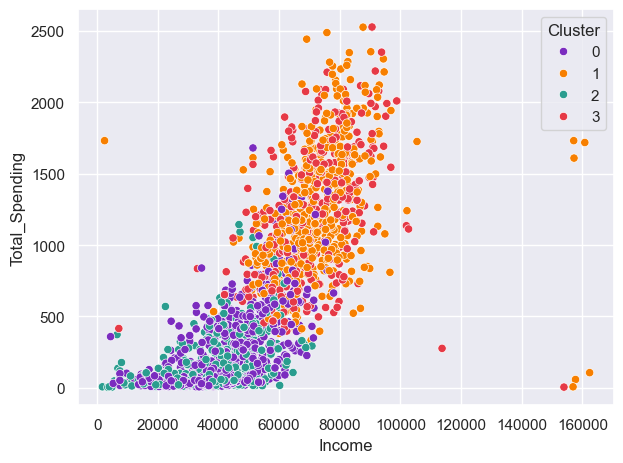

In [46]:
# Income v/s Spendings
sns.set_theme(style="darkgrid")
fig,ax = plt.subplots()

sns.scatterplot(
    x = df["Income"],
    y = df["Total_Spending"],
    hue = df["Cluster"],
    palette = colors
)

fig.tight_layout()
plt.show()

## Evaluate Clusters Quality

In [47]:
# Evaluate CLusters Quality

print("Silhouette Score:", silhouette_score(X_pca,df["Cluster"]))

Silhouette Score: 0.3792545615707937


## Cluster Summary

In [48]:
# Cluster Summary
cluster_summary = df.groupby("Cluster").mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Partner
Cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


## Conclusion
## 0. Budget Family Shoppers =>	Low income, low spending, more children, partnered customers
## 1.	Premium Loyal Customers =>	High income, highest spending, frequent purchases across channels
## 2	Low-Value Solo Shoppers	Lowest income, lowest spending, mostly single customers
## 3.	High-Value Responsive Customers	=> High income, high spending, highest marketing response